# Results Window
- In GPR18, I wrote some code that takes in a dataset and performs the analysis of the predictions, including comparing the performance of the GPR predictions to the ground truth.
- Here, we want to loop through it to create a window analysis of one dataset.
- Once verified that this works and that it fails gracefully, functionalise for CSD3 run.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import emcee

from scipy.optimize import minimize
from scipy.special import softmax

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

from scipy.stats import norm

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.df_ops import prepare_df, split_df, clean_df
from helpers.priors import find_classify_signals, get_priors

def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

def lnPost(log_params, gp, k, y, initial_guesses, bounds, prior_std=3):
    if np.any(log_params < bounds[:, 0]) or np.any(log_params > bounds[:, 1]):
        return -np.inf
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    ll = gp.log_likelihood(y)
    if not np.isfinite(ll):
        return -np.inf
    return ll - 0.5 * np.sum(((np.exp(log_params) - np.exp(initial_guesses)) / prior_std) ** 2)

def plot_trace(sampler, param_names=None):
    samples = sampler.get_chain()  # shape: (n_steps, n_walkers, n_params)
    n_steps, n_walkers, n_params = samples.shape

    if param_names is None:
        param_names = [f"param_{i}" for i in range(n_params)]

    fig, axes = plt.subplots(n_params, 1, figsize=(10, 2.5 * n_params), sharex=True)
    if n_params == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(np.exp(samples[:, :, i]), color="steelblue", alpha=0.3, lw=0.7)
        ax.set_ylabel(param_names[i])
        ax.yaxis.set_label_coords(-0.1, 0.5)

    axes[-1].set_xlabel("Step")
    axes[0].set_title("MCMC Trace")
    fig.tight_layout()
    plt.show()


In [2]:
# ---- PARAMS ----
datapath            = r"../../Data/benchmark/HD201091_Mt_wilson_data.txt"
direct_bound_tol    = 0.1
sm2016_bound_tol    = 0.2
mean_bound_tol      = 1
add_prefix          = False
relative            = True
train_split         = 0.6
valid_split         = 0.15 
star_type           = "G"
star_name           = "HD201091"
error_percent       = 2.5
sigma_upper_mult    = 5.0
q_bounds_in         = [1, 5]  # THIS HAS BEEN CHANGED
verbose             = True
plot                = True
loop_verbose        = True
loop_plot           = True
loop_savefigs       = False
sampler_plot        = True
result_plot_cadence = 50
result_plot_extra   = 1000
require_mid         = True
total_sample_count  = 5000
plot_every          = 200
subsample           = 2000
n_walkers           = 32
valid_metric        = "CRPS"
SEED                = 1701

In [ ]:
#------Ingest and prep data-----
raw_df   = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)
data_df  = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

# Check datapoints
if len(data_df) < 100:
    print("Data has less than 100 datapoints.")
    # SKIP DATASET

# Check span
span = data_df['year'].iloc[-1] - data_df['year'].iloc[0]
if span < 1:
    print("Data spans less than 1 year!")
    # SKIP DATASET

# Check gaps
gaps = data_df['year'].diff().dropna()
if max(gaps) > (span/10):
    print("Biggest gap is greater than 10% of span!")

- If we split by span, there is no guarantee that there will be points in every split.
- Instead, we can split by datapoints but also have a minimum span.

[0.075 0.15  0.225 0.3   0.375 0.45  0.525 0.6   0.675 0.75 ]
+--------+-------------+-------------+------------+-----------+-------------+
| Window | Train Split | Valid Split | Test Split | Train Idx | Retrain Idx |
+--------+-------------+-------------+------------+-----------+-------------+
|   1    |    0.075    |    0.100    |   0.825    |    221    |     736     |
|   2    |    0.150    |    0.227    |   0.623    |    442    |     1552    |
|   3    |    0.225    |    0.206    |   0.569    |    662    |     1931    |
|   4    |    0.300    |    0.239    |   0.461    |    883    |     2470    |
|   5    |    0.375    |    0.167    |   0.458    |    1104   |     2700    |
+--------+-------------+-------------+------------+-----------+-------------+


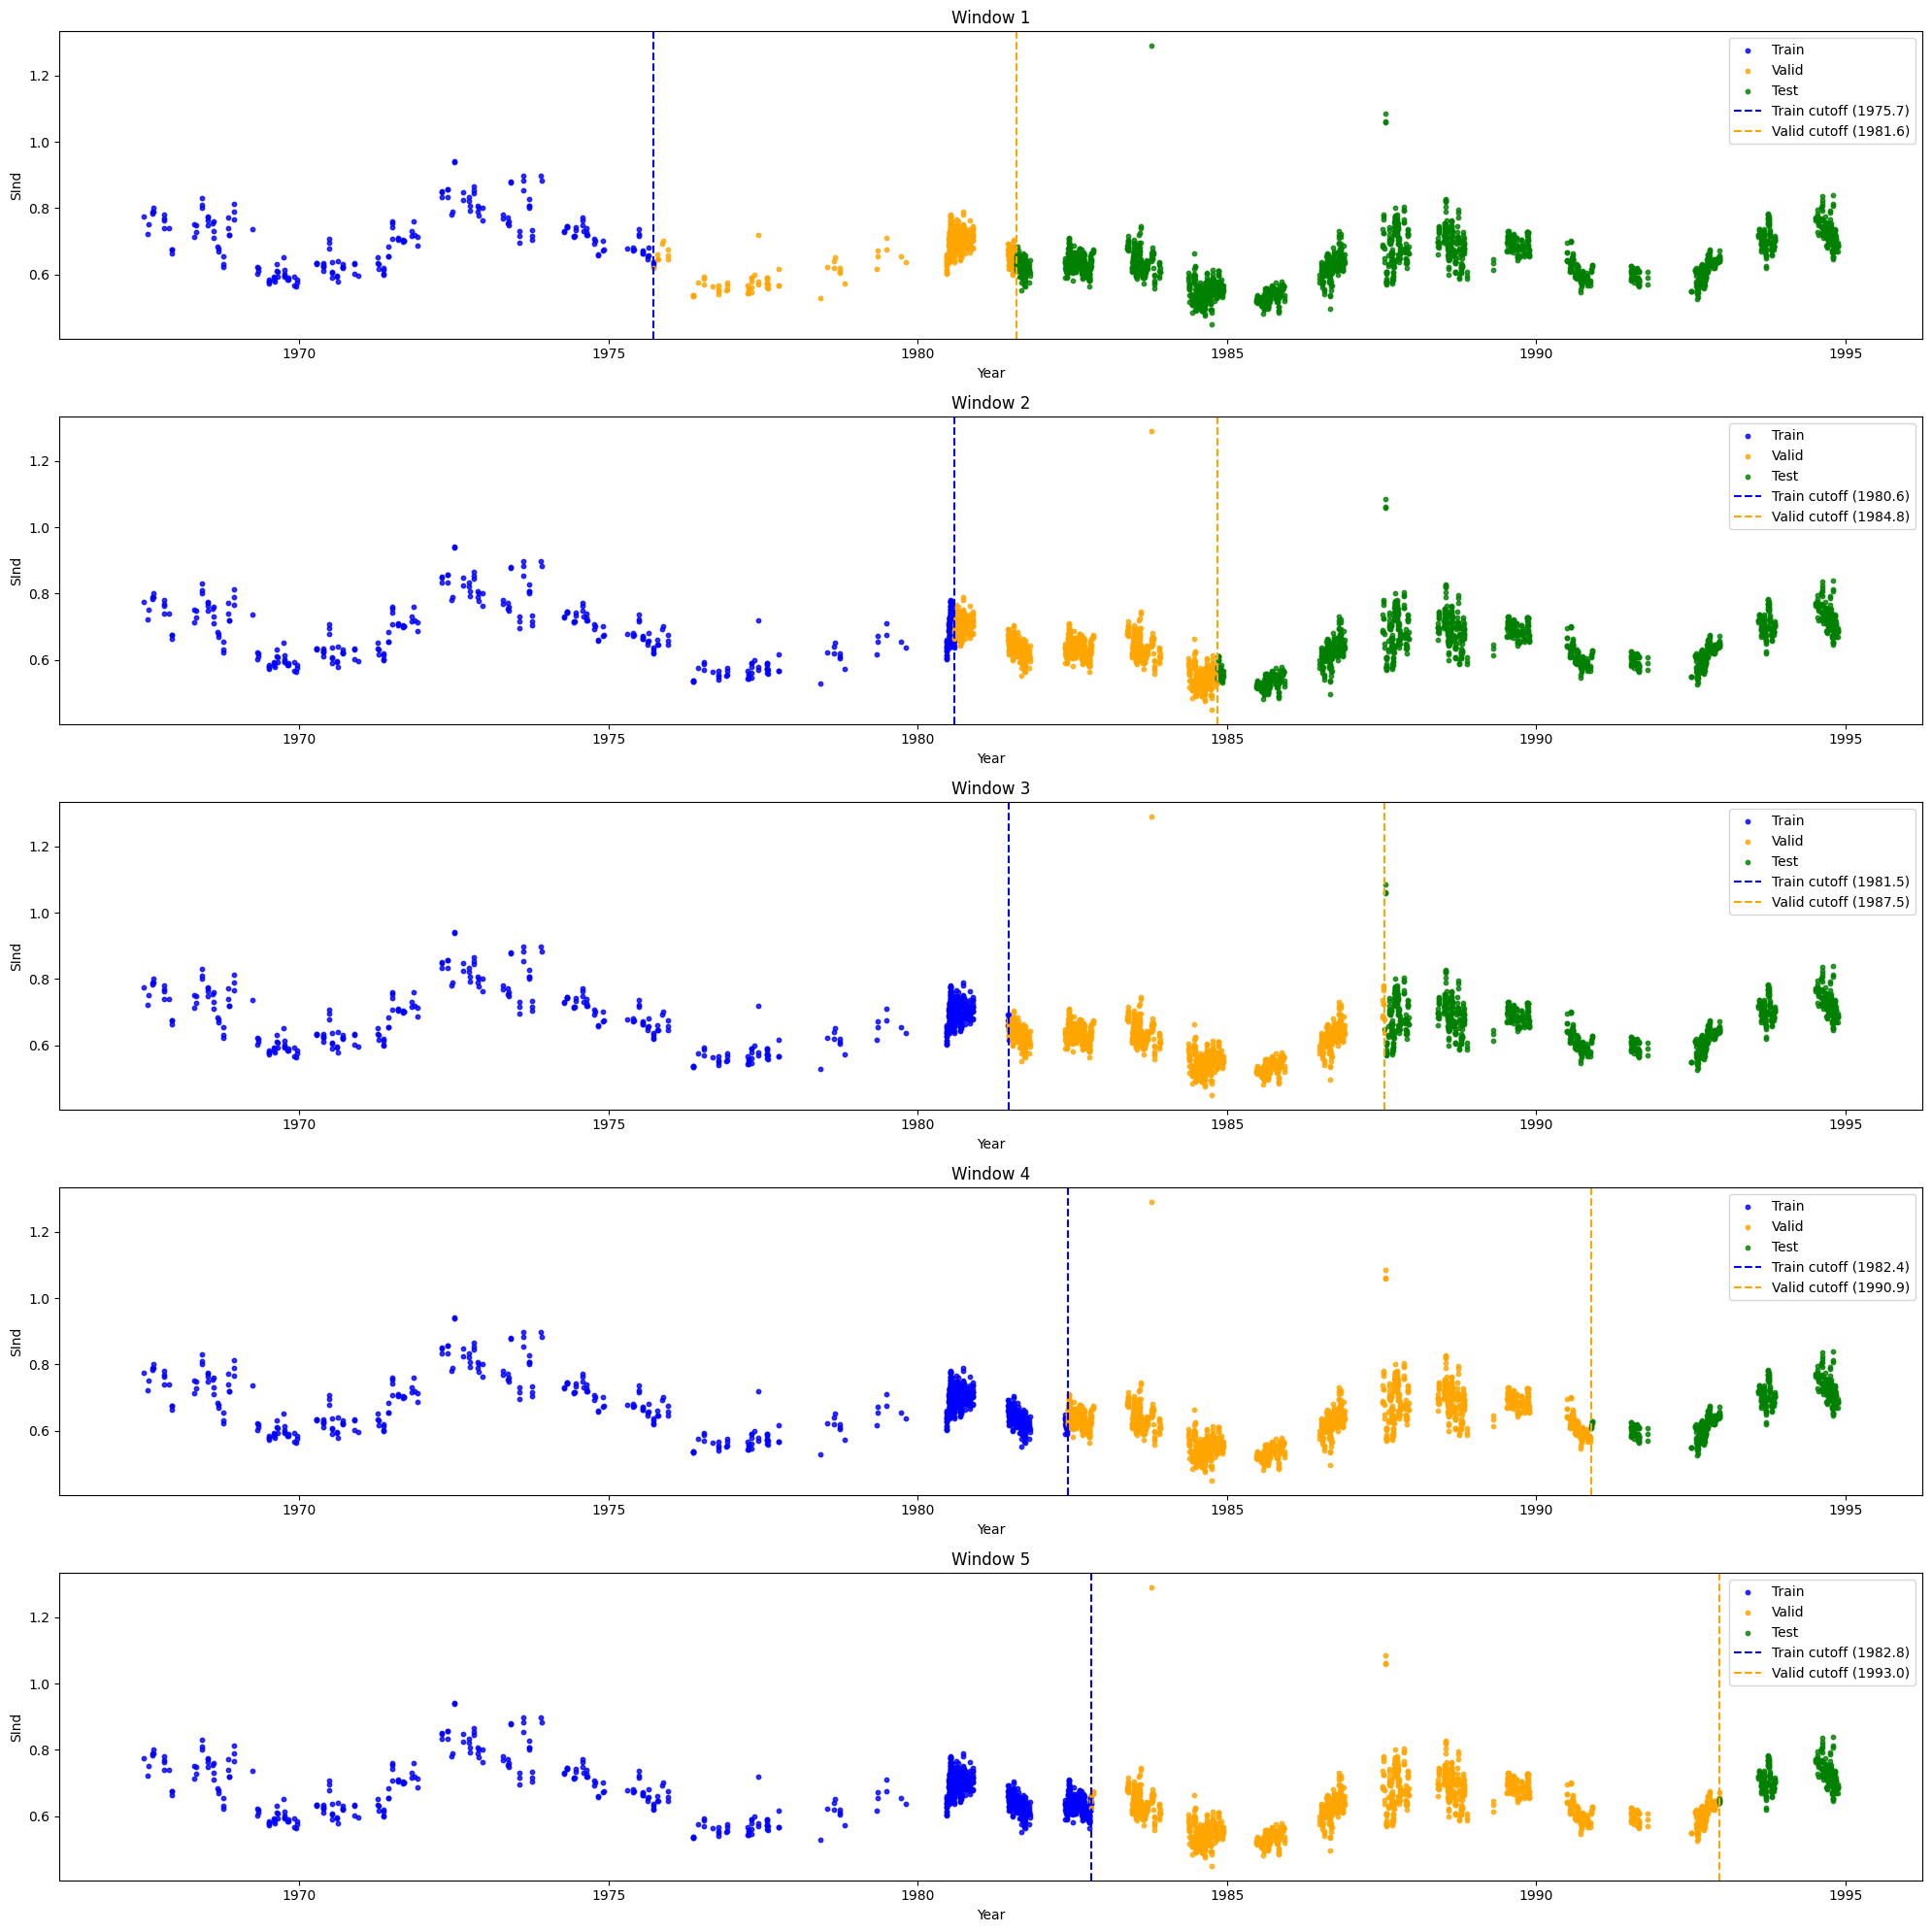

In [ ]:
n_windows = 10 # Targeted number of windows

# Minimum train_split is the larger of 0.75/n_windows or 15% of span
divide_train_splits = [(0.75 / n_windows) * n for n in range(1,n_windows+1)] 
span_train_split = (data_df['year'] < data_df['year'].iloc[0] + 0.15 * span).sum() / len(data_df) # Gets the frac to make it cover 15% of the span
raw_train_splits = np.maximum(divide_train_splits, span_train_split)
train_splits = np.unique(raw_train_splits) # Makes sure they are unique; leaves min of 1
train_idxs = np.round(len(data_df) * train_splits).astype(int)

# Validation split is the either 0.1 of points or frac giving at leas 10% of span
hard_valid_split = 0.1
span_valid_splits = np.array([ 
      (data_df['year'] < data_df['year'].iloc[idx] + 0.1 * span).sum() / len(data_df) - ts
      for idx, ts in zip(train_idxs, train_splits)
  ])
valid_splits = np.maximum(0.1, span_valid_splits) # Validation fractions
valid_idxs = np.round(len(data_df) * valid_splits).astype(int) + train_idxs

# Check if any remains
retraining_split = train_splits + valid_splits # just a diagnostic to see if less than 1; retraining will make sense later
mask = retraining_split < 1 
valid_splits = valid_splits[mask]
train_splits = train_splits[mask]
retraining_split = retraining_split[mask]

# Remaining is test and remove any with a span of less than 1 year
retraining_idxs = train_idxs + valid_idxs
mask_in_bounds = retraining_idxs < len(data_df)

retraining_idxs = retraining_idxs[mask_in_bounds]
train_idxs = train_idxs[mask_in_bounds]
valid_idxs = valid_idxs[mask_in_bounds]
train_splits = train_splits[mask_in_bounds]
valid_splits = valid_splits[mask_in_bounds]
test_splits = (1 - retraining_split)[mask_in_bounds]


# If empty, skip the dataset
if len(test_splits) < 1:
    print("WARNING: No valid splits, using fallback: 1yr test, 50/50 train/valid.")
    test_split = (data_df['year'] >= data_df['year'].iloc[-1] - 1).sum() / len(data_df)
    remaining = 1 - test_split
    train_splits = np.array([remaining / 2])
    valid_splits = np.array([remaining / 2])
    test_splits = np.array([test_split])
    train_idxs = np.round(len(data_df) * train_splits).astype(int)
    valid_idxs = np.round(len(data_df) * valid_splits).astype(int)
    retraining_idxs = train_idxs + valid_idxs

# Make sure they sum to 1
split_totals = test_splits + train_splits + valid_splits
if not np.all(np.isclose(split_totals, 1)):
    print("ERROR: SPLITS DO NOT SUM TO 1")

split_verbose = True
if split_verbose:
    table = PrettyTable()
    table.field_names = ["Window", "Train Split", "Valid Split", "Test Split", "Train Idx", "Retrain Idx"]
    for i, (tr, v, te, ti, ri) in enumerate(zip(train_splits, valid_splits, test_splits, train_idxs, retraining_idxs)):
        table.add_row([i+1, f"{tr:.3f}", f"{v:.3f}", f"{te:.3f}", ti, ri])
    print(table)

split_plot = True
if split_plot:
    n_wins = len(train_splits)
    fig, axes = plt.subplots(n_wins, 1, figsize=(20, 4 * n_wins), sharex=False)
    if n_wins == 1:
        axes = [axes]

    years = data_df['year'].values
    sinds = data_df['sind'].values

    for i, ax in enumerate(axes):
        train_year = years[train_idxs[i]]
        retrain_year = years[retraining_idxs[i]]

        ax.scatter(years[:train_idxs[i]], sinds[:train_idxs[i]], s=10, alpha=0.8, color='blue', label='Train')
        ax.scatter(years[train_idxs[i]:retraining_idxs[i]], sinds[train_idxs[i]:retraining_idxs[i]], s=10, alpha=0.8, color='orange', label='Valid')
        ax.scatter(years[retraining_idxs[i]:], sinds[retraining_idxs[i]:], s=10, alpha=0.8, color='green', label='Test')

        ax.axvline(train_year,   color='blue',   linestyle='--', label=f'Train cutoff ({train_year:.1f})')
        ax.axvline(retrain_year, color='orange', linestyle='--', label=f'Valid cutoff ({retrain_year:.1f})')

        ax.set_xlabel("Year")
        ax.set_ylabel("SInd")
        ax.set_title(f"Window {i+1}")
        ax.legend()

plt.tight_layout()
plt.show()

- Now define the test windows from the test set length.